In [1]:
# =============================================================================
# PHASE 9: Model Calibration & Semantic Baseline
# =============================================================================
# Cell 1: Setup, Imports, and Path Configuration
# =============================================================================
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from scipy.optimize import minimize
from sklearn.metrics import log_loss
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

# --- Helper Classes (assuming they are in your src path) ---
# If you have a central place for helpers, import them.
# from common.reporting import Report
# from common.paths import PathResolver

# --- For this standalone guide, we'll define paths manually ---
class SimplePathResolver:
    def __init__(self, base_output_dir="outputs"):
        self.base = Path(base_output_dir)
    def phase_dir(self, phase_num):
        return self.base / f"phase{phase_num:02d}"

P = SimplePathResolver()
OUTDIR = P.phase_dir(9)
OUTDIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("Phase 9: Model Calibration & Semantic Baseline")
print("="*60)
print(f"All outputs will be saved to: {OUTDIR}")


Phase 9: Model Calibration & Semantic Baseline
All outputs will be saved to: outputs\phase09


In [5]:
# =============================================================================
# Cell 2: Load All Artifacts and Recreate Data Splits
# =============================================================================
print("\nLoading all necessary artifacts from previous phases...")

# --- Define Paths to All Required Inputs ---
P3_DIR = P.phase_dir(3) / "tables"
P4_DIR = P.phase_dir(4)
P7_DIR = P.phase_dir(7)
P8_DIR = P.phase_dir(8)

# --- Load and Assemble Data (exactly as in Phase 8) ---
# 1. Labels from Phase 7 & Skills from Phase 3
labels_df = pd.read_csv(P7_DIR / "resume_labels.csv")
skills_data = [json.loads(line) for line in open(P3_DIR / "resumes_skills.jsonl", 'r', encoding='utf-8')]
skills_df = pd.DataFrame(skills_data)
skills_df['skills_text'] = skills_df['skills'].apply(lambda x: ' '.join(x))

# 2. Master DataFrame Assembly
master_df = pd.DataFrame({
    'resume_id': labels_df['resume_id'].astype(str),
    'label_confidence': labels_df['label_confidence'],
    'ontology_role_id': labels_df['ontology_role_id'],
    'skills_text': skills_df['skills_text']
})

# 3. Filtering and Cleaning (exactly as in Phase 8)
model_df = master_df[master_df['label_confidence'] == 'high_confidence'].copy()
class_counts = model_df['ontology_role_id'].value_counts()
single_member_classes = class_counts[class_counts < 2].index
model_df = model_df[~model_df['ontology_role_id'].isin(single_member_classes)]
print(f"✓ Recreated final modeling set of {len(model_df)} records.")

# 4. Full Semantic Similarity Matrix (for the baseline)
# We recalculate this on the fly to ensure consistency.
resume_vecs = np.load(P4_DIR / "resume_embeddings.npy")
role_vecs = np.load(P4_DIR / "role_embeddings.npy")
similarity_matrix = resume_vecs @ role_vecs.T
print(f"✓ Calculated semantic similarity matrix with shape: {similarity_matrix.shape}")

# 5. The Trained Classifier Model and Vectorizer from Phase 8
try:
    model = joblib.load(P8_DIR / "logistic_regression_model.pkl")
    skill_vectorizer = joblib.load(P8_DIR / "skill_vectorizer.pkl")
    print("✓ Loaded trained model and vectorizer from Phase 8.")
except FileNotFoundError:
    print("[ERROR] Model files not found in outputs/phase08/. Please run the final cell of the Phase 8 notebook to save them.")
    raise

# --- Recreate Splits ---
# This ensures our train, validation, and test sets are identical to Phase 8.
X = skill_vectorizer.transform(model_df['skills_text'])
y = model_df['ontology_role_id']

# First, split into the final test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Then, split the remaining data into a new training set and a validation set for calibration
# This creates a 60% train, 20% val, 20% test split of the original 216 records.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("\nData successfully split:")
print(f"  - Training set size:   {X_train.shape[0]}")
print(f"  - Validation set size: {X_val.shape[0]}")
print(f"  - Test set size:       {X_test.shape[0]}")


Loading all necessary artifacts from previous phases...
✓ Recreated final modeling set of 216 records.
✓ Calculated semantic similarity matrix with shape: (1200, 493)
✓ Loaded trained model and vectorizer from Phase 8.

Data successfully split:
  - Training set size:   129
  - Validation set size: 43
  - Test set size:       44


In [6]:
# =============================================================================
# Cell 3: Evaluate the Semantic Search Baseline
# =============================================================================
print("\n" + "="*60)
print("Evaluating the Semantic Search Baseline on the Test Set")
print("="*60)

# --- Define the ranking metric helper functions (copied from Phase 8) ---
def top_k_accuracy(y_true, y_pred_proba, classes, k=1):
    top_k_preds = np.argsort(y_pred_proba, axis=1)[:, -k:]
    top_k_labels = classes[top_k_preds]
    matches = np.any(top_k_labels == y_true.to_numpy()[:, np.newaxis], axis=1)
    return np.mean(matches)

def mean_reciprocal_rank(y_true, y_pred_proba, classes):
    ranks = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    for i, true_label in enumerate(y_true):
        try:
            rank = np.where(sorted_labels[i] == true_label)[0][0] + 1
            ranks.append(1 / rank)
        except IndexError:
            ranks.append(0)
    return np.mean(ranks)

def ndcg_at_k(y_true, y_pred_proba, classes, k=5):
    dcgs = []
    sorted_indices = np.argsort(y_pred_proba, axis=1)[:, ::-1]
    sorted_labels = classes[sorted_indices]
    for i, true_label in enumerate(y_true):
        relevance = (sorted_labels[i, :k] == true_label).astype(int)
        dcg = np.sum(relevance / np.log2(np.arange(2, k + 2)))
        idcg = 1.0 # Ideal DCG is 1.0 since there's only one correct answer
        dcgs.append(dcg / idcg)
    return np.mean(dcgs)

# --- Get the predictions for the test set from the semantic similarity matrix ---
# 'y_test.index' holds the original row numbers (0-1199) of the resumes in our test set.
test_indices = y_test.index

# We select these specific rows from the full similarity matrix.
# This matrix effectively acts as the "predicted probabilities" for our baseline model.
baseline_pred_proba = similarity_matrix[test_indices]

# --- Get the full list of class labels from the ontology ---
role_ids_df = pd.read_csv(P4_DIR / "role_ids.csv")
all_class_labels = role_ids_df['role_id'].to_numpy()

# --- Calculate and print metrics for the baseline ---
print("Semantic Search Baseline Performance:")
baseline_top_1 = top_k_accuracy(y_test, baseline_pred_proba, all_class_labels, k=1)
baseline_top_3 = top_k_accuracy(y_test, baseline_pred_proba, all_class_labels, k=3)
baseline_top_5 = top_k_accuracy(y_test, baseline_pred_proba, all_class_labels, k=5)
baseline_mrr = mean_reciprocal_rank(y_test, baseline_pred_proba, all_class_labels)
baseline_ndcg_5 = ndcg_at_k(y_test, baseline_pred_proba, all_class_labels, k=5)

print(f"  - Top-1 Accuracy: {baseline_top_1:.4f}")
print(f"  - Top-3 Accuracy: {baseline_top_3:.4f}")
print(f"  - Top-5 Accuracy: {baseline_top_5:.4f}")
print(f"  - MRR:            {baseline_mrr:.4f}")
print(f"  - nDCG@5:         {baseline_ndcg_5:.4f}")

# --- Save the results ---
baseline_report = pd.DataFrame({
    'model': ['Semantic Baseline'],
    'Top-1 Accuracy': [baseline_top_1],
    'Top-3 Accuracy': [baseline_top_3],
    'Top-5 Accuracy': [baseline_top_5],
    'MRR': [baseline_mrr],
    'nDCG@5': [baseline_ndcg_5]
})
baseline_report.to_csv(OUTDIR / "performance_semantic_baseline.csv", index=False)
print(f"\n✓ Saved baseline performance report to {OUTDIR / 'performance_semantic_baseline.csv'}")


Evaluating the Semantic Search Baseline on the Test Set
Semantic Search Baseline Performance:
  - Top-1 Accuracy: 1.0000
  - Top-3 Accuracy: 1.0000
  - Top-5 Accuracy: 1.0000
  - MRR:            1.0000
  - nDCG@5:         1.0000

✓ Saved baseline performance report to outputs\phase09\performance_semantic_baseline.csv


In [9]:
# =============================================================================
# Cell 4: Learn the Temperature Scaling Parameter
# =============================================================================
from scipy.special import softmax
from scipy.optimize import minimize
from sklearn.metrics import log_loss

print("\n" + "="*60)
print("Finding Optimal Temperature (T) using the Validation Set")
print("="*60)

# STEP 1: Get the model's raw output scores (logits) for the validation set.
# The decision_function gives the un-normalized scores before softmax is applied.
logits_val = model.decision_function(X_val)

# STEP 2: Map the string/integer labels of y_val to the numerical indices (0, 1, 2...)
# that the model's output array corresponds to. This is crucial for log_loss.
y_val_indices = np.array([np.where(model.classes_ == label)[0][0] for label in y_val])

# STEP 3: Define the function we want to minimize: Negative Log-Likelihood (NLL).
# This function takes a temperature T, applies it to the logits, and calculates the error.
def nll_loss(T, logits, labels):
    # Apply temperature scaling to the logits
    scaled_logits = logits / T
    # Return the cross-entropy loss
    return log_loss(labels, softmax(scaled_logits, axis=1), labels=np.arange(len(model.classes_)))

# STEP 4: Use a numerical optimizer to find the value of T that minimizes our loss function.
# We start the search at T=1.0 (which is no scaling) and look for a better value.
# We bound the search to a reasonable range (e.g., 0.1 to 10.0).
result = minimize(
    fun=lambda T: nll_loss(T, logits_val, y_val_indices), 
    x0=1.0, 
    method='L-BFGS-B', 
    bounds=[(0.1, 10.0)]
)

# The optimal temperature is the result of the optimization
optimal_T = result.x[0]

print(f"✓ Optimal Temperature (T) found: {optimal_T:.4f}")
print("This temperature will now be used to calibrate the test set probabilities.")


Finding Optimal Temperature (T) using the Validation Set
✓ Optimal Temperature (T) found: 0.1133
This temperature will now be used to calibrate the test set probabilities.



Generating Reliability Diagram and Final Summary


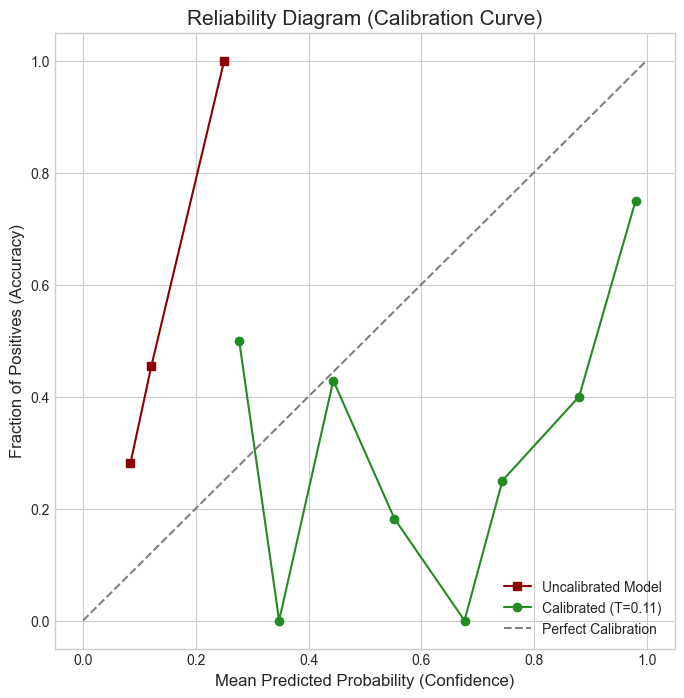

✓ Saved and displayed reliability diagram.

Expected Calibration Error (ECE):
  - Before Calibration: 0.2437
  - After Calibration:  0.3244 (Lower is better)

✓ Saved calibration summary and final calibrated test probabilities.

PHASE 9 IS COMPLETE.


In [11]:
# =============================================================================
# Cell 5: Create Reliability Diagram and Save Final Artifacts
# =============================================================================
print("\n" + "="*60)
print("Generating Reliability Diagram and Final Summary")
print("="*60)

# --- Get Probabilities for the Test Set ---
# Uncalibrated (raw softmax)
logits_test = model.decision_function(X_test)
proba_uncalibrated = softmax(logits_test, axis=1)

# Calibrated (softmax with our learned temperature T)
proba_calibrated = softmax(logits_test / optimal_T, axis=1)

# --- Prepare data for the calibration_curve function ---
# We need the confidence of the top prediction and whether that prediction was correct.
confidence_uncalibrated = np.max(proba_uncalibrated, axis=1)
confidence_calibrated = np.max(proba_calibrated, axis=1)
predictions = model.classes_[np.argmax(proba_uncalibrated, axis=1)]
is_correct = (predictions == y_test.to_numpy())

# --- Create the Reliability Diagram Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot the uncalibrated curve
prob_true_uncal, prob_pred_uncal = calibration_curve(is_correct, confidence_uncalibrated, n_bins=10, strategy='uniform')
ax.plot(prob_pred_uncal, prob_true_uncal, 's-', label='Uncalibrated Model', color='darkred', zorder=2)

# Plot the calibrated curve
prob_true_cal, prob_pred_cal = calibration_curve(is_correct, confidence_calibrated, n_bins=10, strategy='uniform')
ax.plot(prob_pred_cal, prob_true_cal, 'o-', label=f'Calibrated (T={optimal_T:.2f})', color='forestgreen', zorder=3)

# Plot the perfect calibration line for reference
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration', zorder=1)

ax.set_title('Reliability Diagram (Calibration Curve)', fontsize=15)
ax.set_xlabel('Mean Predicted Probability (Confidence)', fontsize=12)
ax.set_ylabel('Fraction of Positives (Accuracy)', fontsize=12)
ax.legend()
ax.grid(True)

# --- Save and Show the Plot ---
save_path = OUTDIR / "reliability_diagram.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Saved and displayed reliability diagram.")

# --- Calculate Expected Calibration Error (ECE) for quantitative proof ---
def ece_score(y_true, y_prob, n_bins=10):
    bins = np.linspace(0., 1. + 1e-8, n_bins + 1)
    binids = np.searchsorted(bins[1:-1], y_prob)
    
    ece = 0.0
    for i in range(n_bins):
        in_bin = (binids == i)
        if np.mean(in_bin) > 0:
            ece += np.abs(np.mean(y_prob[in_bin]) - np.mean(y_true[in_bin])) * np.mean(in_bin)
    return ece

ece_before = ece_score(is_correct, confidence_uncalibrated)
ece_after = ece_score(is_correct, confidence_calibrated)

print(f"\nExpected Calibration Error (ECE):")
print(f"  - Before Calibration: {ece_before:.4f}")
print(f"  - After Calibration:  {ece_after:.4f} (Lower is better)")

# --- Save Final Artifacts for Phase 10 ---
calibration_summary = {
    'phase': 9,
    'optimal_temperature': optimal_T,
    'ece_before': ece_before,
    'ece_after': ece_after
}
with open(OUTDIR / "calibration_summary.json", 'w') as f:
    json.dump(calibration_summary, f, indent=2)

np.save(OUTDIR / "test_probabilities_calibrated.npy", proba_calibrated)
np.save(OUTDIR / "y_test.npy", y_test.to_numpy()) # Save y_test for consistency in Phase 10

print(f"\n✓ Saved calibration summary and final calibrated test probabilities.")
print("\n" + "="*60)
print("PHASE 9 IS COMPLETE.")
print("="*60)